# Inject ParticleGroup into Tao/PyTao

In [1]:
from pytao import Tao
from pmd_beamphysics import ParticleGroup

# Parameters


In [2]:
TRACK_START = "BEAM0" # Where to start particle tracking (injection element)
TRACK_END = "OTR0H04" # Where to end particle tracking

# Get particles from Lume-Impact sc_inj model, e.g.: 
# I.particles['final_particles'].write('impact_particles_at_14m.h5')

PFILE0 = 'impact_particles_at_14m.h5' 

# File to write
PFILE = f'bmad_particles_at_{TRACK_START}.h5' 

# Twiss Match parameters (optional) 
twiss_match = False
beta_x0  =  10
alpha_x0 = 0
beta_y0  =  10
alpha_y0 = 0

# Initialize Tao and get reference time

In [3]:
tao = Tao(f'-init $LCLS_LATTICE/bmad/models/sc_hxr/tao.init -slice BEGINNING:{TRACK_END}')
tao.cmd('place floor sigmaxy')

[]

In [4]:
t_ref = tao.evaluate(f'ele::{TRACK_START}[ref_time]')[0]

t_ref

4.748981151469578e-08

# Prepare particles

In [5]:
P = ParticleGroup(PFILE0)

# Change to s-coordinates (different times t, constant z)
P.drift_to_z() # drift to P['mean_z']

# Zero out the mean time
P.t += t_ref -P['mean_t']

if twiss_match:
    P.twiss_match(beta =  beta_x0  , alpha =alpha_x0, plane = 'x', inplace = True)
    P.twiss_match(beta =  beta_y0  , alpha =alpha_y0, plane = 'y', inplace = True)

# Write the file that Tao will read
P.write(PFILE)

# Check particles

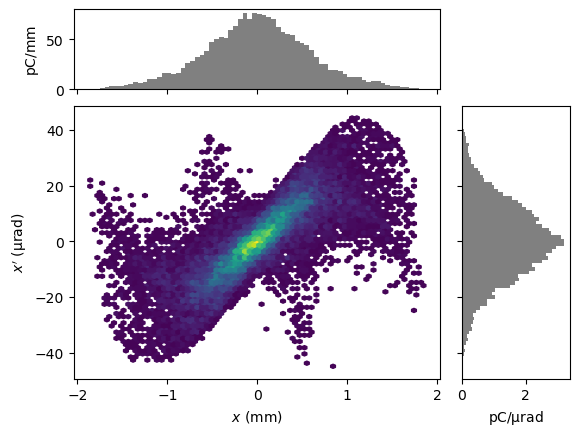

In [6]:
P.plot('x', 'xp')

In [7]:
P['mean_t']

4.748981151469578e-08

In [8]:
P.twiss('xy')

{'alpha_x': -1.0969161706100634,
 'beta_x': 63.49465056601834,
 'gamma_x': 0.03469938121881701,
 'emit_x': 5.575004647800334e-09,
 'eta_x': -1.5486490983370883e-05,
 'etap_x': 6.6462974568762635e-06,
 'norm_emit_x': 9.817254642448271e-07,
 'alpha_y': -1.097445010657698,
 'beta_y': 63.65641017472816,
 'gamma_y': 0.03462943551744024,
 'emit_y': 5.557051434678989e-09,
 'eta_y': 0.00028511722060054737,
 'etap_y': -1.5079031815054574e-05,
 'norm_emit_y': 9.785640092147955e-07}

# # Set initial beam 

In [9]:
tao.cmd('set global plot_on = F')
tao.cmd('set global lattice_calc_on = F')
tao.cmd(f'set beam_init position_file = {PFILE}')
tao.cmd(f'set beam_init track_start = {TRACK_START}')
tao.cmd(f'set beam_init track_end = {TRACK_END}')
tao.cmd(f'set beam_init bunch_charge = {P.charge}')
tao.cmd(f'set beam_init n_particle = {len(P)}')
tao.cmd('set global lattice_calc_on = T')
tao.cmd('set global plot_on = T')

[]

# Track

In [10]:
# Toggle beam
tao.cmd('set global track_type = beam;set global track_type = single') 

['',
 'Tao: set global track_type = beam',
 '',
 'Tao: set global track_type = single']

# Get partices at end

In [11]:
P1 = ParticleGroup(data=tao.bunch_data(TRACK_END))

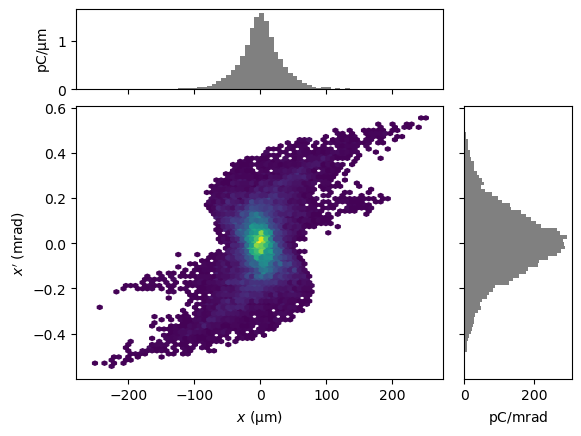

In [12]:
P1.plot('x', 'xp')

# Plot

In [13]:
%%tao
x-a all s
sc

-------------------------
Tao> x-a all s
-------------------------
Tao> sc
-------------------------
Tao> 
